# Logistic Regression and kNN Classification

- Group: Group 1 (Mason DeWitt, Elena Van, Prithvi Ghale)
- Dataset: Dataset 5 (Department Shift)

# Task 1: Define the Modeling Problem

The goal is to predict whether a synthetic student requires support.

### Target Variable (y)

The target variable is `Risk`.

- `Risk = 1` means the student requires support.
- `Risk = 0` means the student does not require support.

### Predictor Variables (X)

The predictors are the student-related variables that the model will use to predict `Risk`:

- `Hours_Studied`
- `Attendance_Pct`
- `Previous_GPA`
- `Assignments_Completed`
- `Quiz_Average`
- `Sleep_Hours`
- `Stress_Level`
- `Commute_Minutes`
- `Social_Hours`
- `Caffeine_Cups`

### Excluded Columns

`Synthetic_Record_ID` is excluded because it is only an identifier for each record.

`Split` is excluded because it only tells us whether a row belongs to the training or test set.

In [1]:
import pandas as pd

df = pd.read_csv("../datasets/synthetic_classification_group_1.csv")

df.head()

,Synthetic_Record_ID,Hours_Studied,Attendance_Pct,Previous_GPA,Assignments_Completed,Quiz_Average,Sleep_Hours,Stress_Level,Commute_Minutes,Social_Hours,Caffeine_Cups,Split,Risk
0,G1-0001,8.46,89.95,2.55,8,72.82,6.53,4,14.24,7.95,1,train,0
1,G1-0002,5.57,79.20,1.87,7,64.08,6.17,6,22.21,6.88,1,train,0
2,G1-0003,7.58,98.91,2.63,7,81.37,8.42,2,43.86,7.58,1,train,0
3,G1-0004,5.03,72.13,2.02,6,64.85,6.04,9,12.60,7.70,4,train,1
4,G1-0005,13.92,78.51,3.13,6,81.05,6.05,5,62.46,5.73,1,train,1


# Task 2: Inspect the Data and Fixed Split

In this task, we inspect the dataset before building the models.

We will check:
- the number of records and fields
- data types
- missing values
- duplicate identifiers
- the training and test split
- class proportions for `Risk`
- numeric ranges and unusual observations
- differences between the training and test predictor distributions

Because Group 1 has a **test population shift**, we will pay close attention to whether the predictor values differ between the training and test sets.

We will keep the provided train and test assignments unchanged.

## Dataset Size

In [13]:
df.shape

(1000, 13)

The dataset contains 1,000 records and 13 fields.

## Data Types

In [15]:
df.dtypes

Synthetic_Record_ID          str
Hours_Studied            float64
Attendance_Pct           float64
Previous_GPA             float64
Assignments_Completed      int64
Quiz_Average             float64
Sleep_Hours              float64
Stress_Level               int64
Commute_Minutes          float64
Social_Hours             float64
Caffeine_Cups              int64
Split                        str
Risk                       int64
dtype: object

The dataset contains a mix of numeric and text data.

Most predictor variables are numeric (`float64` or `int64`).

`Synthetic_Record_ID` and `Split` are text (`str`) columns. `Risk` is stored as an integer because its values are 0 or 1.

## Missing Values

In [16]:
df.isnull().sum()

Synthetic_Record_ID      0
Hours_Studied            0
Attendance_Pct           0
Previous_GPA             0
Assignments_Completed    0
Quiz_Average             0
Sleep_Hours              0
Stress_Level             0
Commute_Minutes          0
Social_Hours             0
Caffeine_Cups            0
Split                    0
Risk                     0
dtype: int64

There are no missing values in the dataset. Every column has 0 missing entries.

## Duplicate Identifiers

In [17]:
df["Synthetic_Record_ID"].duplicated().sum()

np.int64(0)

This means that every record has a unnqiue ID and there is no duplicate IDs.

## Train and Test Split

In [19]:
df["Split"].value_counts()

Split
train    750
test     250
Name: count, dtype: int64

The dataset uses a fixed train and test split.

- 750 records are in the training set.
- 250 records are in the test set.

The training set is used to build the models, while the test set is saved for evaluating how well the final models perform on unseen data.

## Risk Class Proportions

In [21]:
df["Risk"].value_counts()

Risk
0    631
1    369
Name: count, dtype: int64

In [22]:
df["Risk"].value_counts(normalize=True)

Risk
0    0.631
1    0.369
Name: proportion, dtype: float64

The dataset contains 631 students with `Risk = 0` and 369 students with `Risk = 1`.

This means:
- 63.1% of the records are `Risk = 0`
- 36.9% of the records are `Risk = 1`

The classes are not perfectly balanced because `Risk = 0` appears more often than `Risk = 1`.

## Risk Class Distribution

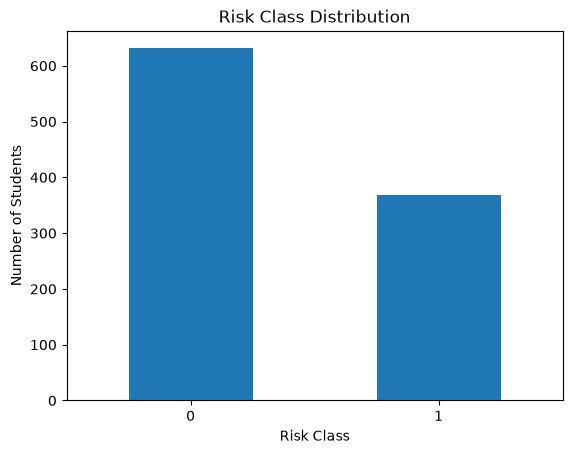

In [24]:
import matplotlib.pyplot as plt

risk_counts = df["Risk"].value_counts().sort_index()

risk_counts.plot(kind="bar")

plt.title("Risk Class Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## Numeric Ranges and Unusual Values

In [25]:
df.describe()

,Hours_Studied,Attendance_Pct,Previous_GPA,Assignments_Completed,Quiz_Average,Sleep_Hours,Stress_Level,Commute_Minutes,Social_Hours,Caffeine_Cups,Risk
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.048930,81.838090,2.77135,6.87600,73.837720,7.285680,4.952000,34.725740,8.342900,3.176000,0.369000
std,3.355516,9.238319,0.42831,1.58655,9.916725,0.935454,1.795249,22.307322,3.238746,2.192677,0.482775
min,1.000000,53.070000,1.40000,2.00000,44.480000,4.270000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,6.727500,75.550000,2.47000,6.00000,67.122500,6.630000,4.000000,16.712500,5.940000,1.000000,0.000000
50%,8.990000,82.015000,2.78000,7.00000,74.010000,7.225000,5.000000,30.500000,7.870000,3.000000,0.000000
75%,11.335000,87.875000,3.06000,8.00000,80.640000,7.940000,6.000000,49.862500,10.625000,5.000000,1.000000
max,18.840000,100.000000,4.00000,10.00000,100.000000,9.700000,10.000000,90.000000,16.000000,8.000000,1.000000


We use summary statistics to check the typical values, minimums, maximums, and overall ranges of the numeric columns.

This helps us look for values that may be unusual or unrealistic before building the models.

The numeric variables have reasonable minimum and maximum values for this synthetic dataset.

For example, GPA ranges from 1.40 to 4.00, attendance ranges from about 53% to 100%, and stress level ranges from 1 to 10.

There are no obviously unrealistic numeric values. Since Group 1 focuses on a test population shift, the more important issue may be differences between the training and test distributions rather than extreme individual values.

## Compare Train and Test Predictor Distributions

Because our group has a test population shift, we compare the predictor values in the training and test sets.

This helps us identify which predictors changed between the two groups.

In [30]:
train_df = df[df["Split"] == "train"]
test_df = df[df["Split"] == "test"]

numeric_features = [
    "Hours_Studied",
    "Attendance_Pct",
    "Previous_GPA",
    "Assignments_Completed",
    "Quiz_Average",
    "Sleep_Hours",
    "Stress_Level",
    "Commute_Minutes",
    "Social_Hours",
    "Caffeine_Cups"
]

comparison = pd.DataFrame({
    "Train Mean": train_df[numeric_features].mean(),
    "Test Mean": test_df[numeric_features].mean()
})

comparison

,Train Mean,Test Mean
Hours_Studied,8.855147,9.63028
Attendance_Pct,81.442027,83.02628
Previous_GPA,2.776267,2.75660
Assignments_Completed,6.886667,6.84400
Quiz_Average,73.832173,73.85436
Sleep_Hours,6.965787,8.24536
Stress_Level,5.090667,4.53600
Commute_Minutes,25.932480,61.10552
Social_Hours,6.995933,12.38380
Caffeine_Cups,2.224000,6.03200


The training and test sets show differences in several predictor averages.

The largest shifts are seen in:
- `Commute_Minutes`, which increases from about 25.93 minutes in training to 61.11 minutes in testing
- `Social_Hours`, which increases from about 7.00 to 12.38 hours
- `Caffeine_Cups`, which increases from about 2.22 to 6.03 cups
- `Sleep_Hours`, which increases from about 6.97 to 8.25 hours

Some predictors, such as `Previous_GPA`, `Assignments_Completed`, and `Quiz_Average`, remain very similar between the training and test sets.

These differences show the test population shift in Group 1.

## Train vs Test Predictor Means

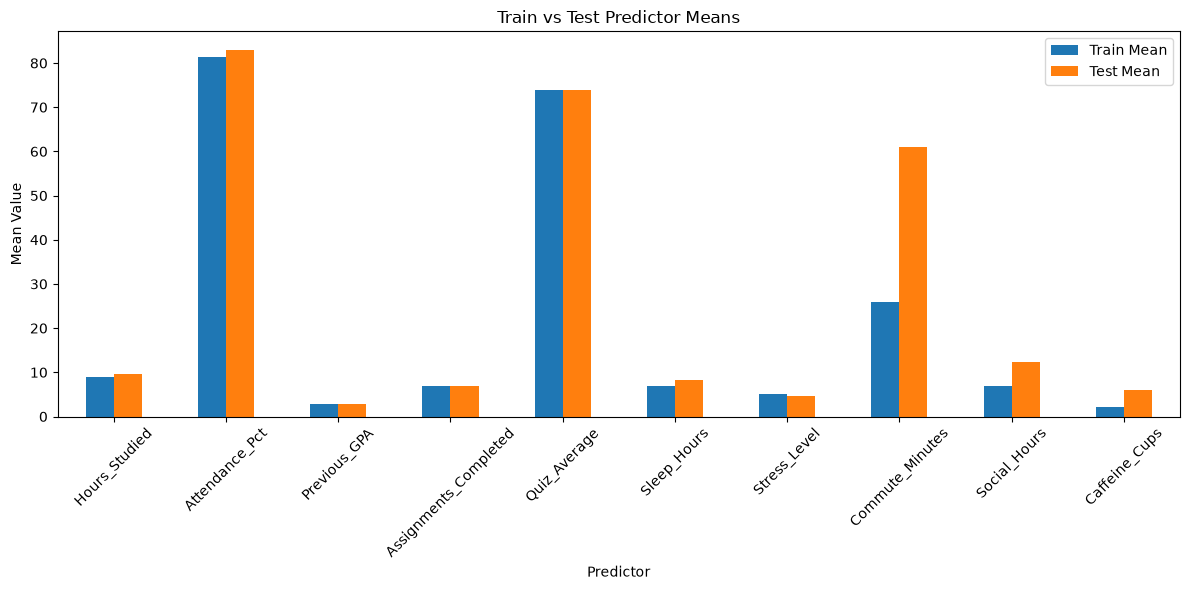

In [32]:
comparison.plot(kind="bar", figsize=(12, 6))

plt.title("Train vs Test Predictor Means")
plt.xlabel("Predictor")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The graph makes the population shift easier to see. The largest differences between the training and test sets appear in `Commute_Minutes`, `Social_Hours`, `Caffeine_Cups`, and `Sleep_Hours`.

These predictors have noticeably different average values in the test population compared with the training population.

## Distributions of the Most Shifted Predictors

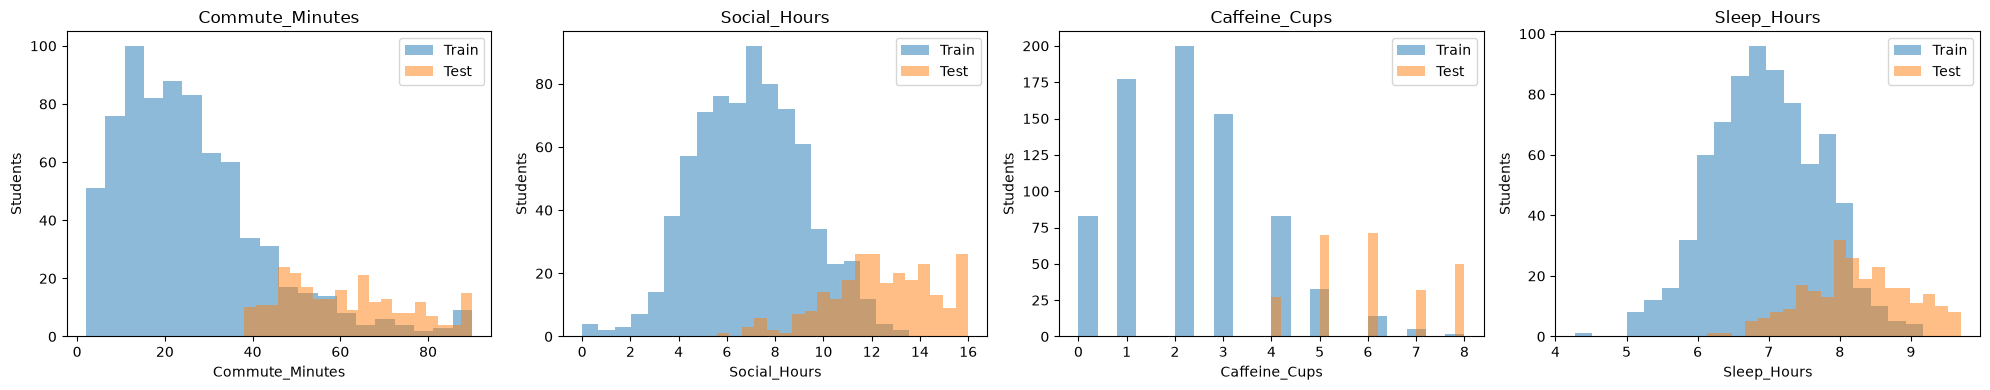

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

shifted_features = [
    "Commute_Minutes",
    "Social_Hours",
    "Caffeine_Cups",
    "Sleep_Hours"
]

for ax, feature in zip(axes, shifted_features):
    ax.hist(train_df[feature], bins=20, alpha=0.5, label="Train")
    ax.hist(test_df[feature], bins=20, alpha=0.5, label="Test")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Students")
    ax.legend()

plt.tight_layout()
plt.show()

The distribution plots show a clear population shift between the training and test sets.

The largest differences appear in:
- `Commute_Minutes`: test students tend to have longer commutes.
- `Social_Hours`: test students tend to have more social hours.
- `Caffeine_Cups`: test students tend to consume more caffeine.
- `Sleep_Hours`: test students tend to get more sleep.

The train and test distributions do not completely overlap, which means the test population has different characteristics from the population the models are trained on.

## Train and Test Risk Proportions

In [36]:
pd.crosstab(
    df["Split"],
    df["Risk"],
    normalize="index"
)

Risk,0,1
Split,,
test,0.636000,0.364000
train,0.629333,0.370667


The class proportions are very similar between the training and test sets.

- Training set: about 62.9% are `Risk = 0` and 37.1% are `Risk = 1`
- Test set: about 63.6% are `Risk = 0` and 36.4% are `Risk = 1`

This means the population shift in Group 1 is mainly in the predictor values, not in the overall `Risk` class balance.

# Task 3: Prepare the Predictors

In this task, we prepare the predictor variables that will be used by the classification models.

All predictor variables in Group 1 are numeric, so no categorical encoding is needed.

We will:
- use the numeric predictor columns as `X`
- use `Risk` as the target `y`
- keep the provided training and test split
- exclude `Synthetic_Record_ID` and `Split`
- standardize the numeric predictors inside each model pipeline

Keeping the scaling inside the pipeline helps prevent data leakage because the scaler is fit only on the training data.

## Define the Predictor Variables

In [37]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Pct",
    "Previous_GPA",
    "Assignments_Completed",
    "Quiz_Average",
    "Sleep_Hours",
    "Stress_Level",
    "Commute_Minutes",
    "Social_Hours",
    "Caffeine_Cups"
]

The `numeric_features` list contains the predictor variables that will be used by the models.

`Synthetic_Record_ID` and `Split` are excluded, and `Risk` is not included because it is the target variable.

## Create the Training and Test Sets

In [38]:
train_data = df["Split"] == "train"
test_data = df["Split"] == "test"

X_train = df.loc[train_data, numeric_features]
X_test = df.loc[test_data, numeric_features]

y_train = df.loc[train_data, "Risk"]
y_test = df.loc[test_data, "Risk"]

`X_train` and `X_test` contain the predictor variables.

`y_train` and `y_test` contain the target variable, `Risk`.

The provided train and test assignments are kept unchanged so the models can be trained on the training rows and evaluated later on the untouched test rows.

In [39]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (750, 10)
X_test shape: (250, 10)
y_train shape: (750,)
y_test shape: (250,)


The shapes confirm that the fixed split was created correctly.

- `X_train` contains 750 training records and 10 predictor variables.
- `X_test` contains 250 test records and 10 predictor variables.
- `y_train` and `y_test` contain the matching `Risk` values for those records.

## Prepare for Scaling

The numeric predictors will be standardized using `StandardScaler`.

We will not scale the full dataset ahead of time. Instead, scaling will be placed inside each model pipeline so that the scaler is fit only on the training data.

This helps prevent data leakage from the test set.

In [41]:
from sklearn.preprocessing import StandardScaler

# Task 4: Fit Scaled Logistic Regression

In this task, a Logistic Regression model is built to predict `Risk`.

The model uses:
- `StandardScaler` to standardize the numeric predictors
- `LogisticRegression(max_iter=2000)` to perform the classification

Scaling is included inside the pipeline so it is learned only from the training data.

After fitting the model, we examine the standardized coefficients and odds ratios to understand how each predictor is associated with the probability of `Risk = 1`.

In [42]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scaling is inside the pipeline so it is fit on training rows only
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])
logistic_model.fit(X_train, y_train)

logreg = logistic_model.named_steps["logreg"]

coef_table = pd.DataFrame({
    "Std Coefficient": logreg.coef_[0],
    "Odds Ratio": np.exp(logreg.coef_[0])
}, index=numeric_features)

# Order by strength of association (absolute coefficient)
coef_table = coef_table.reindex(
    coef_table["Std Coefficient"].abs().sort_values(ascending=False).index
)

print(
    f"Intercept (log-odds of Risk=1 at the average student): "
    f"{logreg.intercept_[0]:.3f}\n"
)

coef_table.round(3)

Intercept (log-odds of Risk=1 at the average student): -0.916



,Std Coefficient,Odds Ratio
Previous_GPA,-0.707,0.493
Hours_Studied,-0.688,0.502
Attendance_Pct,-0.664,0.515
Stress_Level,0.529,1.697
Quiz_Average,-0.374,0.688
Assignments_Completed,-0.366,0.693
Commute_Minutes,0.161,1.175
Social_Hours,0.102,1.107
Caffeine_Cups,-0.067,0.935
Sleep_Hours,-0.061,0.941


## Logistic Regression Coefficients and Odds Ratios

The standardized coefficients show the direction and strength of the relationship between each predictor and `Risk`.

- A positive coefficient means higher values of the predictor are associated with a higher probability of `Risk = 1`.
- A negative coefficient means higher values of the predictor are associated with a lower probability of `Risk = 1`.

The odds ratio gives another way to interpret the same relationship while holding the other predictors constant.

In [44]:
print("Logistic Regression Interpretations:\n")

for feature in numeric_features:
    coef = coef_table.loc[feature, "Std Coefficient"]
    odds_ratio = coef_table.loc[feature, "Odds Ratio"]

    if coef > 0:
        direction = "increases"
    else:
        direction = "decreases"

    print(
        f"{feature}: coefficient = {coef:.2f}, "
        f"odds ratio = {odds_ratio:.2f} → {direction} the odds of Risk=1"
    )

Logistic Regression Interpretations:

Hours_Studied: coefficient = -0.69, odds ratio = 0.50 → decreases the odds of Risk=1
Attendance_Pct: coefficient = -0.66, odds ratio = 0.51 → decreases the odds of Risk=1
Previous_GPA: coefficient = -0.71, odds ratio = 0.49 → decreases the odds of Risk=1
Assignments_Completed: coefficient = -0.37, odds ratio = 0.69 → decreases the odds of Risk=1
Quiz_Average: coefficient = -0.37, odds ratio = 0.69 → decreases the odds of Risk=1
Sleep_Hours: coefficient = -0.06, odds ratio = 0.94 → decreases the odds of Risk=1
Stress_Level: coefficient = 0.53, odds ratio = 1.70 → increases the odds of Risk=1
Commute_Minutes: coefficient = 0.16, odds ratio = 1.18 → increases the odds of Risk=1
Social_Hours: coefficient = 0.10, odds ratio = 1.11 → increases the odds of Risk=1
Caffeine_Cups: coefficient = -0.07, odds ratio = 0.94 → decreases the odds of Risk=1


# Task 5: Tune Scaled kNN

In this task, we test several values of `k` to find the best kNN classification model.

The model uses:
- `StandardScaler` to standardize the numeric predictors
- `KNeighborsClassifier` to classify students as `Risk = 0` or `Risk = 1`

We will test:

`k = 3, 5, 9, 15, 25`

Each value of `k` will be evaluated using 5-fold stratified cross-validation on the training data.

The best value of `k` will be selected using the highest mean balanced accuracy.

## Set Up kNN Tuning

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

k_values = [3, 5, 9, 15, 25]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=407
)

## Test Each k Value

In [46]:
results = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="balanced_accuracy"
    )

    results.append({
        "k": k,
        "Mean Balanced Accuracy": scores.mean(),
        "Std Dev": scores.std()
    })

results_df = pd.DataFrame(results)

results_df

,k,Mean Balanced Accuracy,Std Dev
0,3,0.708212,0.013379
1,5,0.719929,0.011495
2,9,0.732465,0.017171
3,15,0.739900,0.008421
4,25,0.748730,0.017223


## kNN Tuning Results

The mean balanced accuracy increased as `k` increased across the tested values.

- `k = 3`: about 0.708
- `k = 5`: about 0.720
- `k = 9`: about 0.732
- `k = 15`: about 0.740
- `k = 25`: about 0.749

We select the model with the **highest mean balanced accuracy** because a higher balanced accuracy means the model performs better across both `Risk = 0` and `Risk = 1`.

We are not choosing `k = 25` simply because 25 is the largest value. We are choosing it because it produced the highest balanced accuracy out of the values we tested.

Therefore, `k = 25` is selected as the final kNN value.

## Balanced Accuracy by k Value

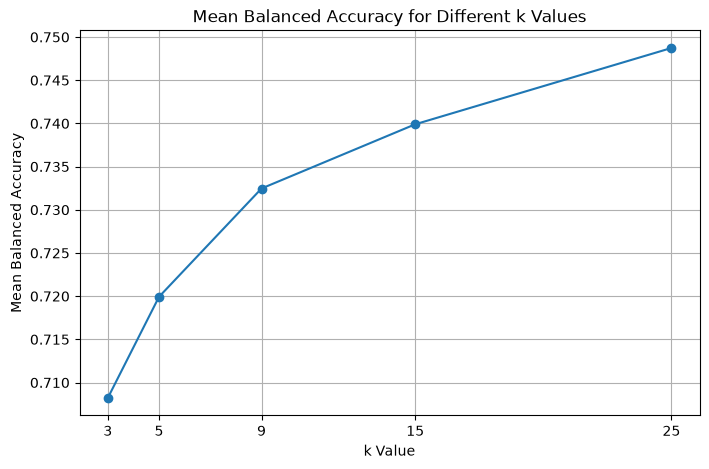

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k"],
    results_df["Mean Balanced Accuracy"],
    marker="o"
)

plt.title("Mean Balanced Accuracy for Different k Values")
plt.xlabel("k Value")
plt.ylabel("Mean Balanced Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

The graph shows that mean balanced accuracy increased as `k` increased across the tested values.

The highest balanced accuracy occurs at `k = 25`, which confirms that `k = 25` is the selected value for the final kNN model.
